<a href="https://colab.research.google.com/github/Cpreets/Car-Price-Predictions-Project-2-/blob/main/decision_tree_evaluation_data_201.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Introduction

The dataset used in this project was obtained from Kaggle and contains information about used cars. Each row in the dataset represents one vehicle, and the dataset includes over 1,000 rows with both numerical and categorical features. The variables describe different aspects of each car, such as price, mileage, model year, engine size, power, fuel type, transmission, and seating capacity.

The purpose of this project is to analyze the dataset using both unsupervised and supervised machine learning techniques. In the first part, KMeans clustering is used to determine whether there are natural groupings of cars based on features like age, mileage, performance, and price. In the second part, a Decision Tree regression model is built to predict car prices and to understand which features are most influential in determining vehicle value.

The main questions explored in this project include:

- Are there distinct clusters of cars based on their characteristics?

- How do these clusters differ in terms of price, mileage, and performance?

Which features are most important for predicting car prices using a Decision Tree model?

This project follows the full data analysis workflow, including data preparation and wrangling, exploratory data analysis, model training, evaluation, and interpretation of results.

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import r2_score, mean_squared_error


In [ ]:
DATA_PATH = "car_price_dataset_medium.csv"  # put the CSV in the same folder as this script/notebook
df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nHead:")
print(df.head())


Shape: (1000, 12)

Columns: ['Car_ID', 'Brand', 'Model_Year', 'Kilometers_Driven', 'Fuel_Type', 'Transmission', 'Owner_Type', 'Engine_CC', 'Max_Power_bhp', 'Mileage_kmpl', 'Seats', 'Price_USD']

Head:
   Car_ID     Brand  Model_Year  Kilometers_Driven Fuel_Type Transmission  \
0       1      Audi        2005             197018    Diesel       Manual   
1       2       BMW        2019              43467    Hybrid    Automatic   
2       3       Kia        2012             153697    Hybrid    Automatic   
3       4  Mercedes        2015              38893    Petrol    Automatic   
4       5      Audi        2016              81329    Hybrid    Automatic   

  Owner_Type  Engine_CC  Max_Power_bhp  Mileage_kmpl  Seats  Price_USD  
0      First       4046          223.6         29.61      6  119611.94  
1      First       3731          248.4         21.66      5   90842.46  
2      Third       4925          465.5         12.14      6   78432.24  
3     Second       3771          229.7      

In [ ]:
# Missing values
df.isna().sum()

# Drop duplicates
df = df.drop_duplicates()

# Feature engineering
CURRENT_YEAR = 2025
df["Car_Age"] = CURRENT_YEAR - df["Model_Year"]

# Separate numeric & categorical columns
num_cols = df.select_dtypes(include=[np.number]).columns
cat_cols = df.select_dtypes(exclude=[np.number]).columns

# Fill missing values
for c in num_cols:
    df[c] = df[c].fillna(df[c].median())

for c in cat_cols:
    df[c] = df[c].fillna(df[c].mode()[0])

df.head()

,Car_ID,Brand,Model_Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Engine_CC,Max_Power_bhp,Mileage_kmpl,Seats,Price_USD,Car_Age
0,1,Audi,2005,197018,Diesel,Manual,First,4046,223.6,29.61,6,119611.94,20
1,2,BMW,2019,43467,Hybrid,Automatic,First,3731,248.4,21.66,5,90842.46,6
2,3,Kia,2012,153697,Hybrid,Automatic,Third,4925,465.5,12.14,6,78432.24,13
3,4,Mercedes,2015,38893,Petrol,Automatic,Second,3771,229.7,19.65,6,44568.89,10
4,5,Audi,2016,81329,Hybrid,Automatic,First,2817,573.2,7.74,5,8751.82,9


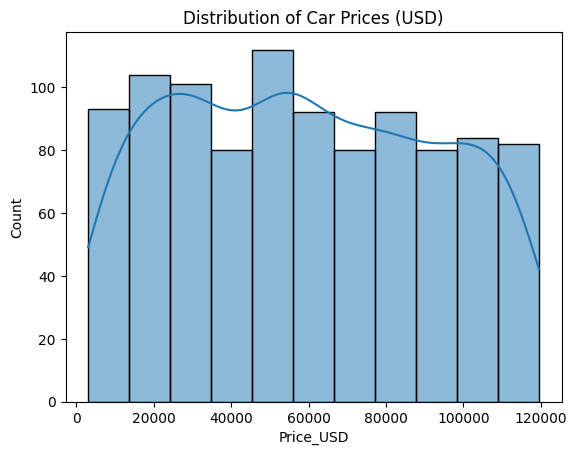

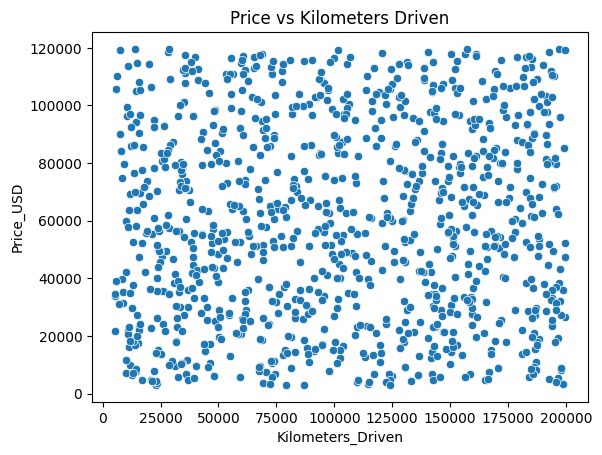

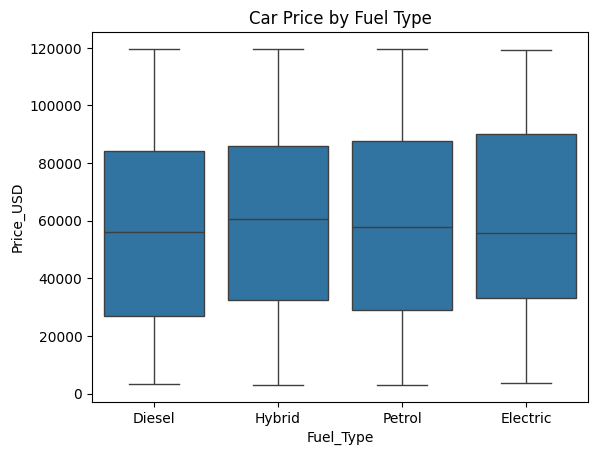

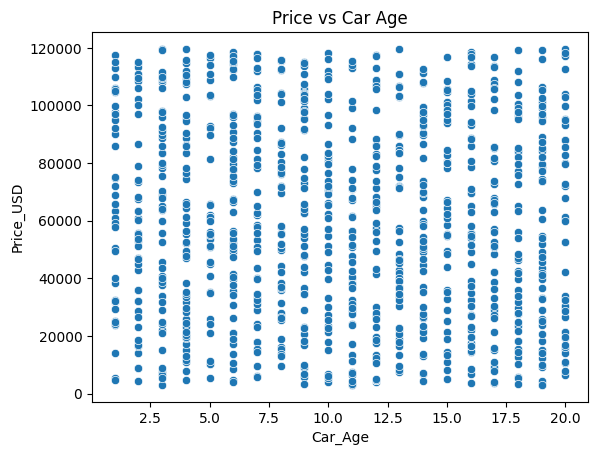

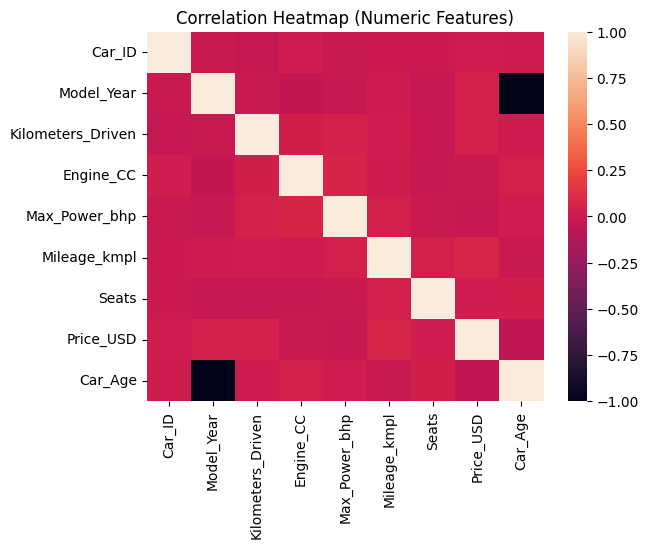

In [ ]:
# ---------------------------
plt.figure()
sns.histplot(df["Price_USD"], kde=True)
plt.title("Distribution of Car Prices (USD)")
plt.xlabel("Price_USD")
plt.ylabel("Count")
plt.show()

plt.figure()
sns.scatterplot(x="Kilometers_Driven", y="Price_USD", data=df)
plt.title("Price vs Kilometers Driven")
plt.xlabel("Kilometers_Driven")
plt.ylabel("Price_USD")
plt.show()

plt.figure()
sns.boxplot(x="Fuel_Type", y="Price_USD", data=df)
plt.title("Car Price by Fuel Type")
plt.xlabel("Fuel_Type")
plt.ylabel("Price_USD")
plt.show()

plt.figure()
sns.scatterplot(x="Car_Age", y="Price_USD", data=df)
plt.title("Price vs Car Age")
plt.xlabel("Car_Age")
plt.ylabel("Price_USD")
plt.show()

plt.figure()
sns.heatmap(df.select_dtypes(include=[np.number]).corr(), annot=False)
plt.title("Correlation Heatmap (Numeric Features)")
plt.show()


In [ ]:
#    Use numeric features + scaling
# ---------------------------
# Choose features for clustering (you can adjust these, but keep it sensible)
kmeans_features = [
    "Car_Age",
    "Kilometers_Driven",
    "Engine_CC",
    "Max_Power_bhp",
    "Mileage_kmpl",
    "Seats",
    "Price_USD"
]

X_cluster = df[kmeans_features].copy()

# Scale features (KMeans is distance-based!)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)


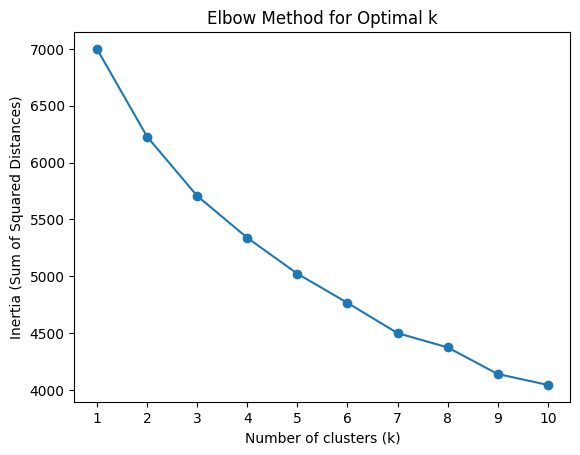

In [ ]:
k_values = range(1, 11)
inertias = []

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init="auto")
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure()
plt.plot(list(k_values), inertias, marker="o")
plt.title("Elbow Method for Optimal k")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia (Sum of Squared Distances)")
plt.xticks(list(k_values))
plt.show()

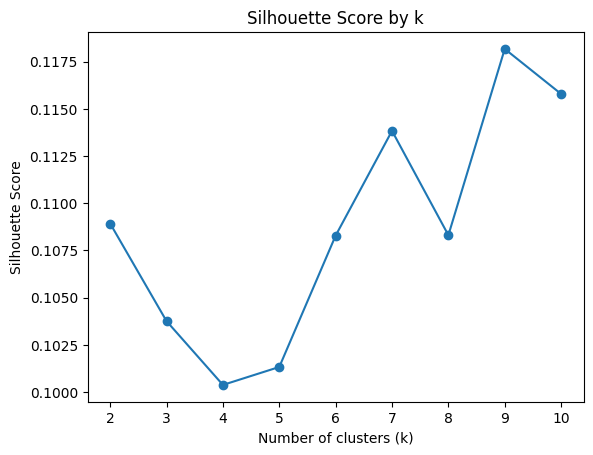

In [ ]:
sil_scores = []
k_values_sil = range(2, 11)

for k in k_values_sil:
    km = KMeans(n_clusters=k, random_state=42, n_init="auto")
    labels = km.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    sil_scores.append(score)

plt.figure()
plt.plot(list(k_values_sil), sil_scores, marker="o")
plt.title("Silhouette Score by k")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette Score")
plt.xticks(list(k_values_sil))
plt.show()

In [ ]:
FINAL_K = 4  # adjust based on elbow/silhouette

kmeans = KMeans(n_clusters=FINAL_K, random_state=42, n_init="auto")
df["Cluster"] = kmeans.fit_predict(X_scaled)

df["Cluster"].value_counts()

,count
Cluster,
3,290
0,250
2,236
1,224


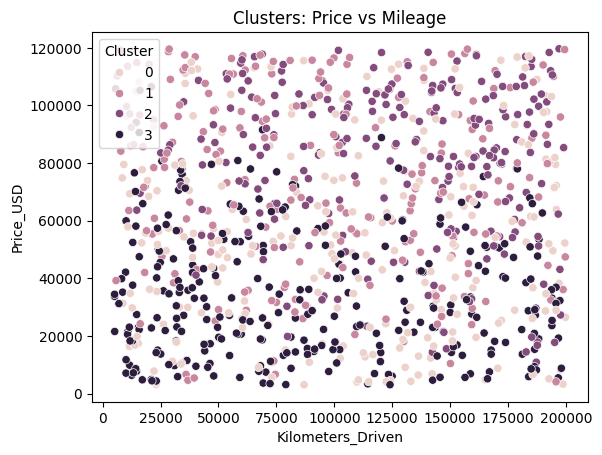

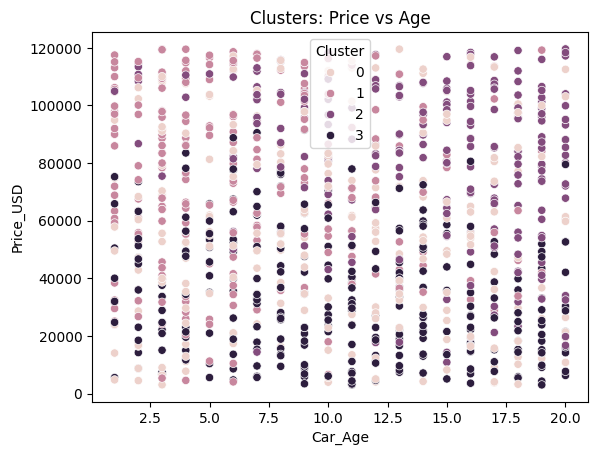

Fuel_Type,Diesel,Electric,Hybrid,Petrol
Cluster,,,,
0,0.212000,0.292000,0.252000,0.244000
1,0.241071,0.290179,0.267857,0.200893
2,0.237288,0.211864,0.224576,0.326271
3,0.213793,0.220690,0.262069,0.303448


In [ ]:
df.groupby("Cluster")[kmeans_features].mean().round(2)
plt.figure()
sns.scatterplot(x="Kilometers_Driven", y="Price_USD", hue="Cluster", data=df)
plt.title("Clusters: Price vs Mileage")
plt.show()

plt.figure()
sns.scatterplot(x="Car_Age", y="Price_USD", hue="Cluster", data=df)
plt.title("Clusters: Price vs Age")
plt.show()

pd.crosstab(df["Cluster"], df["Fuel_Type"], normalize="index")


In [ ]:
target = "Price_USD"
X = df.drop(columns=["Car_ID", "Price_USD"])
y = df[target]

num_features = X.select_dtypes(include=[np.number]).columns
cat_features = X.select_dtypes(exclude=[np.number]).columns

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

In [ ]:
preprocess = ColumnTransformer([
    ("num", "passthrough", num_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features)
])

tree = DecisionTreeRegressor(
    max_depth=6,
    min_samples_leaf=10,
    random_state=42
)

pipe = Pipeline([
    ("preprocess", preprocess),
    ("model", tree)
])

pipe.fit(X_train, y_train)


Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num', 'passthrough',
                                                  Index(['Model_Year', 'Kilometers_Driven', 'Engine_CC', 'Max_Power_bhp',
       'Mileage_kmpl', 'Seats', 'Car_Age', 'Cluster'],
      dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['Brand', 'Fuel_Type', 'Transmission', 'Owner_Type'], dtype='object'))])),
                ('model',
                 DecisionTreeRegressor(max_depth=6, min_samples_leaf=10,
                                       random_state=42))])

In [ ]:
y_pred = pipe.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse:,.2f}")
print(f"R²: {r2:.4f}")

RMSE: 29,928.38
R²: 0.1980


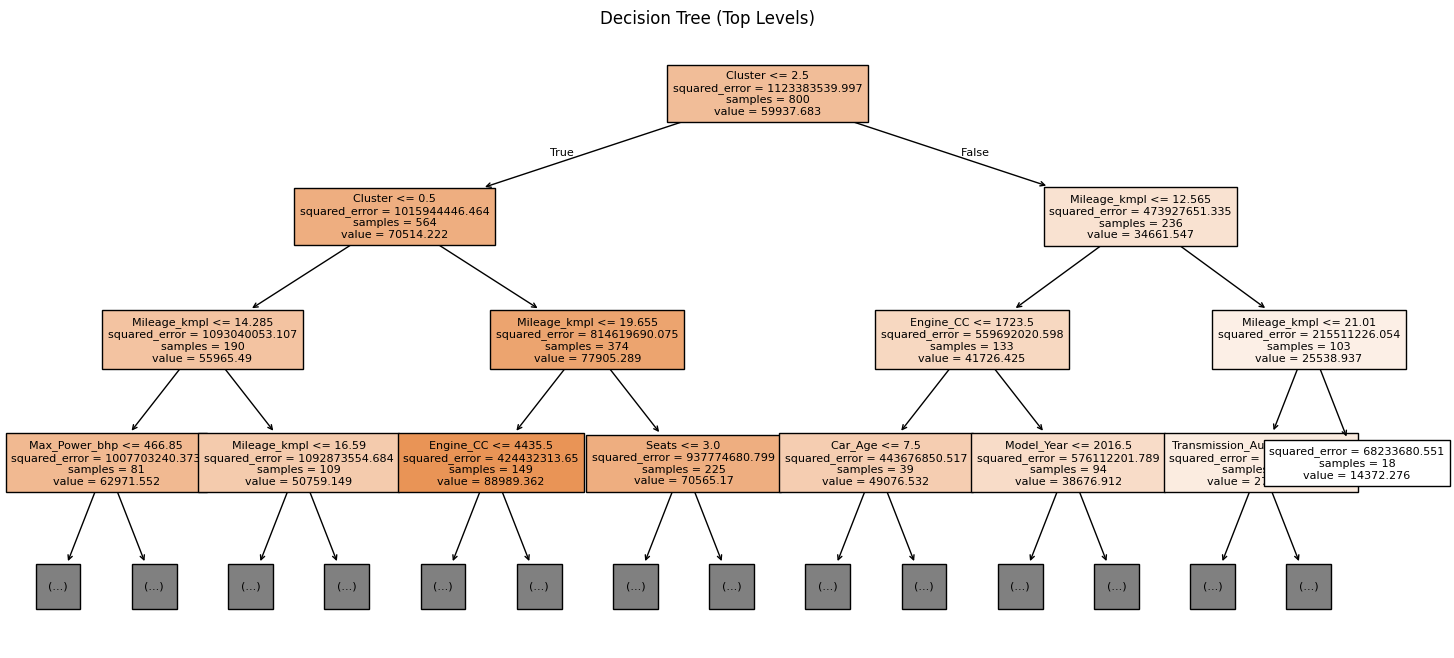

In [ ]:
ohe = pipe.named_steps["preprocess"].named_transformers_["cat"]
ohe_names = ohe.get_feature_names_out(cat_features)

feature_names = np.concatenate([num_features, ohe_names])

plt.figure(figsize=(18, 8))
plot_tree(
    pipe.named_steps["model"],
    feature_names=feature_names,
    filled=True,
    max_depth=3,
    fontsize=8
)
plt.title("Decision Tree (Top Levels)")
plt.show()

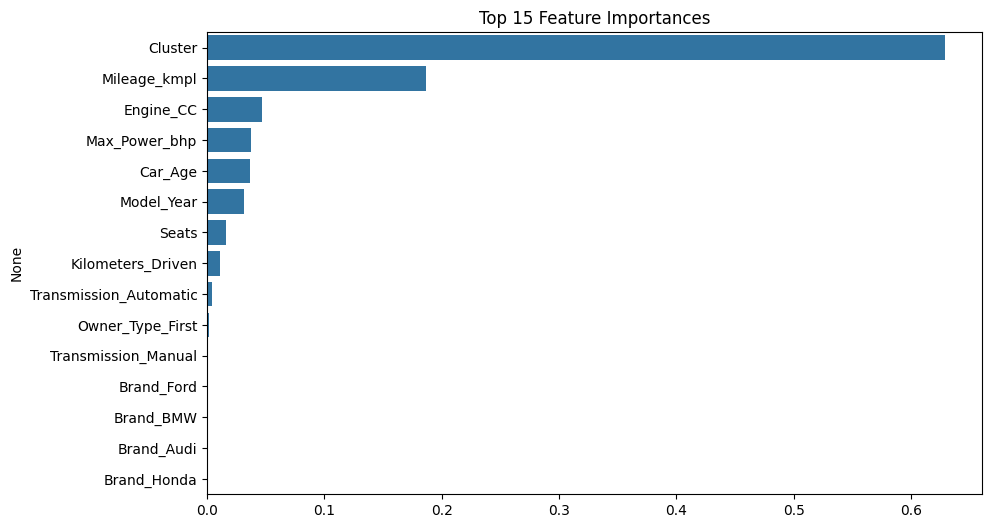

,0
Cluster,0.629211
Mileage_kmpl,0.186170
Engine_CC,0.047018
Max_Power_bhp,0.037346
Car_Age,0.036470
Model_Year,0.031401
Seats,0.016141
Kilometers_Driven,0.010771
Transmission_Automatic,0.003784
Owner_Type_First,0.001280


In [ ]:
importances = pd.Series(
    pipe.named_steps["model"].feature_importances_,
    index=feature_names
)

top_features = importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(10,6))
sns.barplot(x=top_features.values, y=top_features.index)
plt.title("Top 15 Feature Importances")
plt.show()

top_features